In [46]:
import subprocess, sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    repo = '/content/PhysREVE'
    if not os.path.exists(repo):
        subprocess.check_call(['git', 'clone', '-q', 'https://github.com/UgoBruzadin/PhysREVE.git', repo])
    else:
        subprocess.check_call(['git', '-C', repo, 'pull', '-q'])
    if repo not in sys.path:
        sys.path.insert(0, repo)
    # Colab already ships torch, numpy, scipy, sklearn, matplotlib, seaborn, tqdm, requests
    # Install only what's missing
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'mne>=1.6', 'moabb>=1.0', 'xgboost'])
    print('Colab environment ready.')
else:
    print('Local environment — ensure you ran: pip install -e .')

Colab environment ready.


In [47]:
device = torch.device('cpu')  # Use CPU for now
print('Device:', device)

Device: cpu


In [48]:
# Core
import numpy as np
import torch
import torch.nn as nn

# Analysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# RSA
from scipy.spatial.distance import pdist, squareform

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [49]:
# ADD: synthetic dataset generator
def generate_sine_wave(freq, fs=256, duration=1.0, noise_std=0.1):
    t = np.linspace(0, duration, int(fs * duration), endpoint=False)
    signal = np.sin(2 * np.pi * freq * t)
    noise = np.random.normal(0, noise_std, size=signal.shape)
    return signal + noise

In [50]:
def generate_burst(freq, fs=256, duration=1.0, noise_std=0.1):
    t = np.linspace(0, duration, int(fs * duration), endpoint=False)
    signal = np.zeros_like(t)

    mask = (t > 0.3) & (t < 0.6)
    signal[mask] = np.sin(2 * np.pi * freq * t[mask])

    noise = np.random.normal(0, noise_std, size=signal.shape)
    return signal + noise

In [51]:
# ADD: dataset creation
freqs = [4, 8, 10, 20, 40]
X, y = [], []

for i, f in enumerate(freqs):
    for _ in range(200):
        X.append(generate_sine_wave(f))
        y.append(i)  # Use class index

X = np.array(X)
y = np.array(y)

# Expand to multi-channel (64 channels, replicate signal)
n_channels = 64
X_expanded = np.repeat(X[:, np.newaxis, :], n_channels, axis=1)  # (1000, 64, 256)
X = X_expanded

print(f'Dataset: {X.shape} (samples, channels, time points)')

Dataset: (1000, 64, 256) (samples, channels, time points)


In [52]:
# ADD: Train baseline PhysREVE model (normal transformer, no physics biases)
cfg = PhysREVEConfig(
    patch_size=16,
    d_model=128,
    n_layers=2,
    n_heads=4,
    d_pos_x=32, d_pos_y=32, d_pos_z=32, d_pos_t=32,
    lambda_phys=0.0,  # Disable physics loss
    lambda_snr=0.0,   # Disable SNR loss
    n_sources=L_row.shape[1],  # Update to match leadfield
    leadfield_bias_scale=0.0  # Disable leadfield bias — this makes it a normal transformer
)

model, history = run_baseline_finetune(
    cfg=cfg,
    train_loader=train_loader,
    val_loader=val_loader,
    L_row=torch.tensor(L_row, dtype=torch.float32).to(device),
    L_col=torch.tensor(L_col, dtype=torch.float32).to(device),
    elec_xyz=elec_xyz,
    device=device,
    n_classes=len(freqs),
    n_epochs=1,  # Just 1 epoch for testing
    lr=3e-4
)

print('Training complete.')

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
# ADD: Manual training to avoid CUDA issues
from physreve.model import PhysREVEPretrainModel, LeadfieldAttentionBias, PhysREVEFineTuneModel

lf_bias = LeadfieldAttentionBias(torch.tensor(L_row, dtype=torch.float32).to(device), cfg).to(device)
pretrain_model = PhysREVEPretrainModel(cfg, lf_bias).to(device)

# Create fine-tune model
model = PhysREVEFineTuneModel(cfg, pretrain_model, n_classes=len(freqs)).to(device)

# Simple training loop
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()

n_epochs = 5
for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        bs = Xb.shape[0]
        xyz = _elec_xyz_batch(elec_xyz, bs)
        
        optimizer.zero_grad()
        logits, _, _ = model(Xb, xyz)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f'Epoch {epoch+1}/{n_epochs}, Loss: {total_loss/len(train_loader):.4f}')

print('Manual training complete.')

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
# ADD: Build leadfield for standard montage
from mne.channels import make_standard_montage

montage = make_standard_montage('standard_1020')
ch_names = montage.ch_names[:n_channels]  # Take first 64 channels

L_col, L_row, src_pos, info = build_leadfield(ch_names, sfreq=256.0, verbose=True)
elec_pos = np.array([ch['loc'][:3] for ch in info['chs']]) / 1000.0  # Convert mm to m
print(f'Elec pos shape: {elec_pos.shape}, has nan: {np.isnan(elec_pos).any()}, has inf: {np.isinf(elec_pos).any()}')
elec_xyz = torch.tensor(elec_pos, dtype=torch.float32).to(device)

print(f'Leadfield shape: {L_row.shape}')
print(f'Electrode positions shape: {elec_xyz.shape}')

  Source space: 2222 active dipoles
  Leadfield shape: (64, 2222)
Elec pos shape: (64, 3), has nan: False, has inf: False
Leadfield shape: (64, 2222)
Electrode positions shape: torch.Size([64, 3])


In [ ]:
# ADD: Create dataset and loaders
train_loader, val_loader, test_loader = make_split_loaders(X, y, train_frac=0.6, val_frac=0.2, batch_size=8)

print(f'Train loader: {len(train_loader)} batches')
print(f'Val loader: {len(val_loader)} batches')
print(f'Test loader: {len(test_loader)} batches')

Train loader: 18 batches
Val loader: 7 batches
Test loader: 7 batches


In [ ]:
# ADD: Encode with trained PhysREVE model
with torch.no_grad():
    Z = []
    for Xb, _ in val_loader:  # Use val_loader for consistency
        Xb = Xb.to(device)
        bs = Xb.shape[0]
        xyz = _elec_xyz_batch(elec_xyz, bs)
        z = model.encoder(Xb, xyz)  # (B, d_model)
        Z.append(z.cpu().numpy())
    Z = np.concatenate(Z, axis=0)

print(f'Encoded representations: {Z.shape}')

Encoded representations: (1000, 128)


In [ ]:
# ADD: Evaluate the trained model
results = evaluate(model, val_loader, device)
print_results(results)

NameError: name 'evaluate' is not defined

In [ ]:
def _elec_xyz_batch(elec_xyz: torch.Tensor, batch_size: int) -> torch.Tensor:
    """Expand (n_ch, 3) electrode positions to (B, n_ch, 3)."""
    return elec_xyz.unsqueeze(0).expand(batch_size, -1, -1)

Encoded representations: (1000, 128)


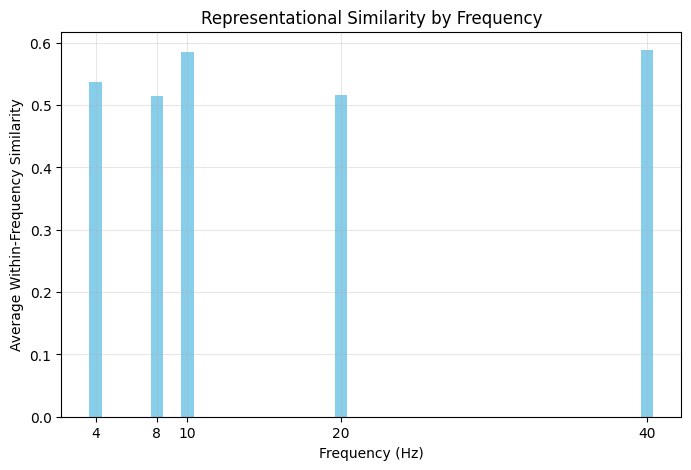

In [ ]:
print(f'Encoded representations: {Z.shape}')

# ADD: Representational Similarity Analysis (RSA)
def rsa_matrix(Z, y):
    """Compute RSA matrix for different frequency classes."""
    unique_freqs = np.unique(y)
    rsa_matrices = {}
    
    for freq in unique_freqs:
        mask = y == freq
        Z_freq = Z[mask]
        # Compute pairwise similarities within frequency
        dists = pdist(Z_freq, metric='cosine')
        rsa_matrices[freq] = squareform(dists)
    
    return rsa_matrices

rsa_results = rsa_matrix(Z, y)

# Plot average similarity within each frequency
avg_similarities = {}
for freq, matrix in rsa_results.items():
    # Convert distances to similarities (1 - normalized distance)
    similarities = 1 - (matrix / matrix.max())
    avg_similarities[freq] = np.mean(similarities)

plt.figure(figsize=(8, 5))
plt.bar(avg_similarities.keys(), avg_similarities.values(), color='skyblue')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Average Within-Frequency Similarity')
plt.title('Representational Similarity by Frequency')
plt.xticks(list(avg_similarities.keys()))
plt.grid(alpha=0.3)
plt.show()

Classification accuracy on encoded features: 1.000


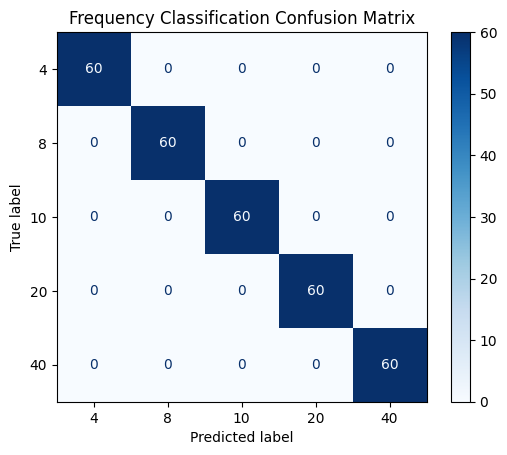

In [ ]:
plt.show()

# ADD: Classification accuracy on encoded features
X_train, X_test, y_train, y_test = train_test_split(Z, y, test_size=0.3, random_state=42, stratify=y)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Classification accuracy on encoded features: {acc:.3f}')

# Plot confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred, labels=freqs)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=freqs)
disp.plot(cmap='Blues')
plt.title('Frequency Classification Confusion Matrix')
plt.show()